# Final Assignment

In [16]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
sns.set(rc={'figure.figsize':(15, 9)})
sns.set(font_scale=1.5)

### Part 1

The `food_consumption.csv` dataset from the `data` folder contains data on the several countries' food consumption per food category and their respective CO2 emissions. Load it to a DataFrame named `food` and check its contents.

In [17]:
food = pd.read_csv("data/food_consumption.csv")

print(food.info())
food.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        1430 non-null   object 
 1   food_category  1430 non-null   object 
 2   consumption    1430 non-null   float64
 3   co2_emission   1430 non-null   float64
dtypes: float64(2), object(2)
memory usage: 44.8+ KB
None


,country,food_category,consumption,co2_emission
0,Argentina,pork,10.51,37.20
1,Argentina,poultry,38.66,41.53
2,Argentina,beef,55.48,1712.00
3,Argentina,lamb_goat,1.56,54.63
4,Argentina,fish,4.36,6.96


1. Use the `.describe()` method on the `food` DataFrame to produce descriptive statistics about the `consumption` metric for each class in the `food_category` variable. **Which `food_category` has the highest median value of `food_consumption`?**

In [18]:
food.groupby('food_category')['consumption'].describe()

,count,mean,std,min,25%,50%,75%,max
food_category,,,,,,,,
beef,130.0,12.123385,9.654140,0.78,4.9975,8.285,17.9400,55.48
dairy,130.0,125.774692,93.327721,3.04,45.7925,110.975,192.7150,430.76
eggs,130.0,8.163769,5.032582,0.16,3.9450,8.420,12.3125,19.15
fish,130.0,17.287077,19.013508,0.24,6.0250,13.950,21.8525,179.71
lamb_goat,130.0,2.600154,3.665252,0.00,0.5600,1.325,3.1025,21.12
nuts,130.0,4.137231,3.372817,0.18,1.8050,3.495,5.6100,23.03
pork,130.0,16.123692,15.717646,0.00,2.0900,10.355,28.2275,67.11
poultry,130.0,21.219231,14.571980,0.47,10.9100,19.855,29.7475,62.50
rice,130.0,29.375154,37.324471,0.95,4.7200,11.875,43.4425,171.73


The `food_category` with the highest median consumption value is *"dairy"* with a value of 192.71 (I think *units consumed*)

2. In a single chart, plot one boxplot for each `food_category` (11 in total) using the variable `co2_emission` as the metric. **By looking at the chart, which `food_category` has the highest interquartile range (IQR)?**

Text(0.5, 1.0, 'food_category - boxplot')

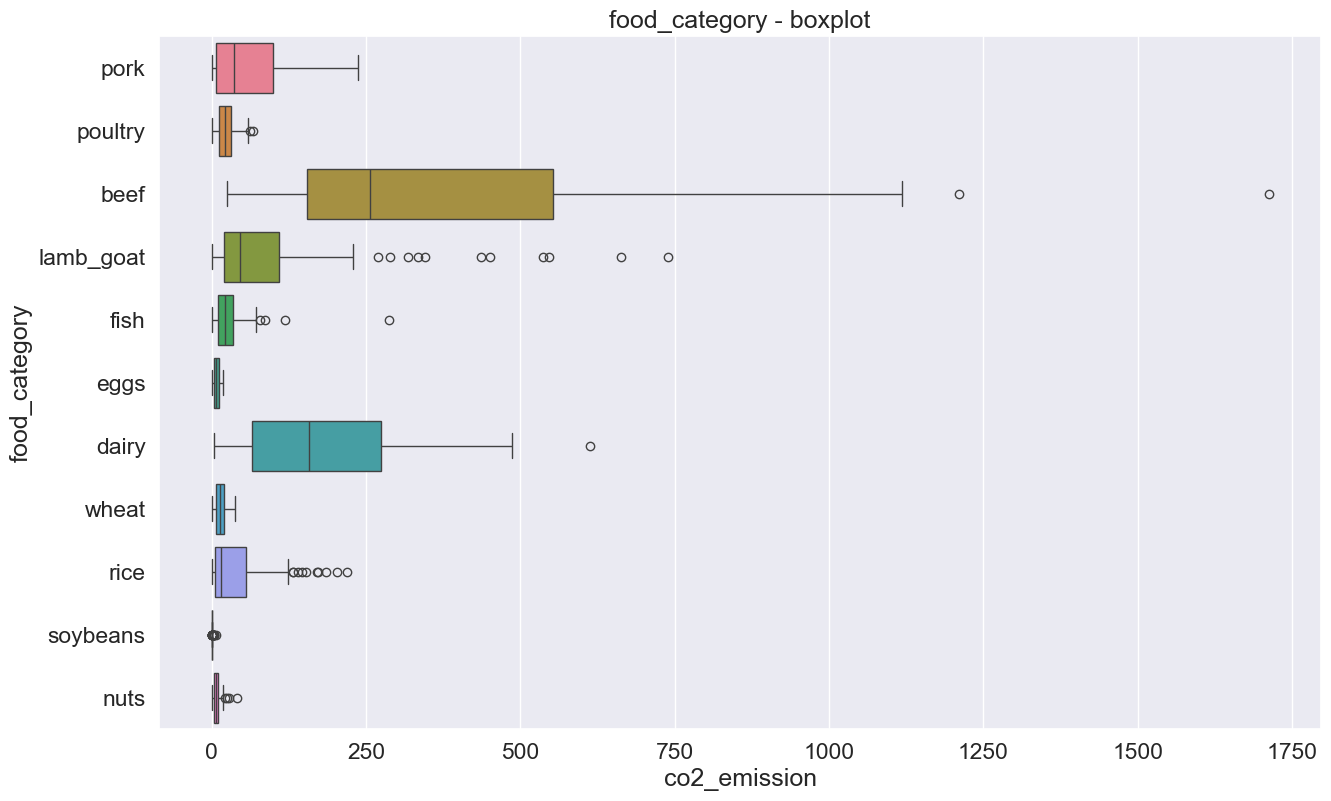

In [19]:
fig = sns.boxplot(data=food, x='co2_emission', y='food_category', hue='food_category')
fig.set_title('food_category - boxplot')

As shown in the graph above, the `food_category` with the highest IQR range is *"beef"*

3. Looking at the chart from the previous question, which is the `food_category` with the highest median `co2_emission` value?

As we can see from the plot, *"beef"* has the highest median value, which is approximately 250 (I think *metric ton*)

4. Consider the `consumption` of "poultry" and "fish" across all available `countries`; looking at the table from question 1, the average of poultry consumption (21.22) seems to be higher than that of fish consumption (17.29), but is this difference statistically significant? Create a permutation test in order to assess the null hypothesis that there is no difference between the two means. **Do you accept or reject the null hypothesis?** Explain why.

In [20]:
food_filtered = food[food['food_category'].isin(['poultry', 'fish'])]
food_filtered.head()

,country,food_category,consumption,co2_emission
1,Argentina,poultry,38.66,41.53
4,Argentina,fish,4.36,6.96
12,Australia,poultry,46.12,49.54
15,Australia,fish,17.69,28.25
23,Albania,poultry,13.23,14.21


In [21]:
food_filtered.reset_index(drop=True, inplace=True)
food_filtered.head()

,country,food_category,consumption,co2_emission
0,Argentina,poultry,38.66,41.53
1,Argentina,fish,4.36,6.96
2,Australia,poultry,46.12,49.54
3,Australia,fish,17.69,28.25
4,Albania,poultry,13.23,14.21


In [22]:
### PERMUTATION TEST ###

# Fish and Poultry mean
mu_poultry = np.mean(food_filtered[food_filtered['food_category'] == 'poultry']['consumption'])
mu_fish = np.mean(food_filtered[food_filtered['food_category'] == 'fish']['consumption'])
mu_diff = mu_poultry - mu_fish

print(f"Mean consumption for Poultry: {mu_poultry}")
print(f"Mean consumption for Fish: {mu_fish}")
print(f"Difference in means: {mu_diff}")

Mean consumption for Poultry: 21.21923076923077
Mean consumption for Fish: 17.28707692307692
Difference in means: 3.9321538461538488


In [23]:
# Permutation
np.random.seed(42)

n = 10000
mu_diff_samples = []
for i in range(n): 
    # extract a subsample of 50% of data without replacement
    df_sample1 = food_filtered.sample(frac=0.5, replace=False)
    # use set() to get indexes of rows that were not extracted from df in previous step
    ix2 = set(food_filtered.index) - set(df_sample1.index)
    # create dataframe with other 50% of data
    df_sample2 = food_filtered.loc[list(ix2)]
    # calculate difference in mean from each sample
    mu_diff_temp = np.mean(df_sample1['consumption']) - np.mean(df_sample2['consumption'])
    # append sampled mean difference to mu_diff_samples list
    mu_diff_samples.append(mu_diff_temp)

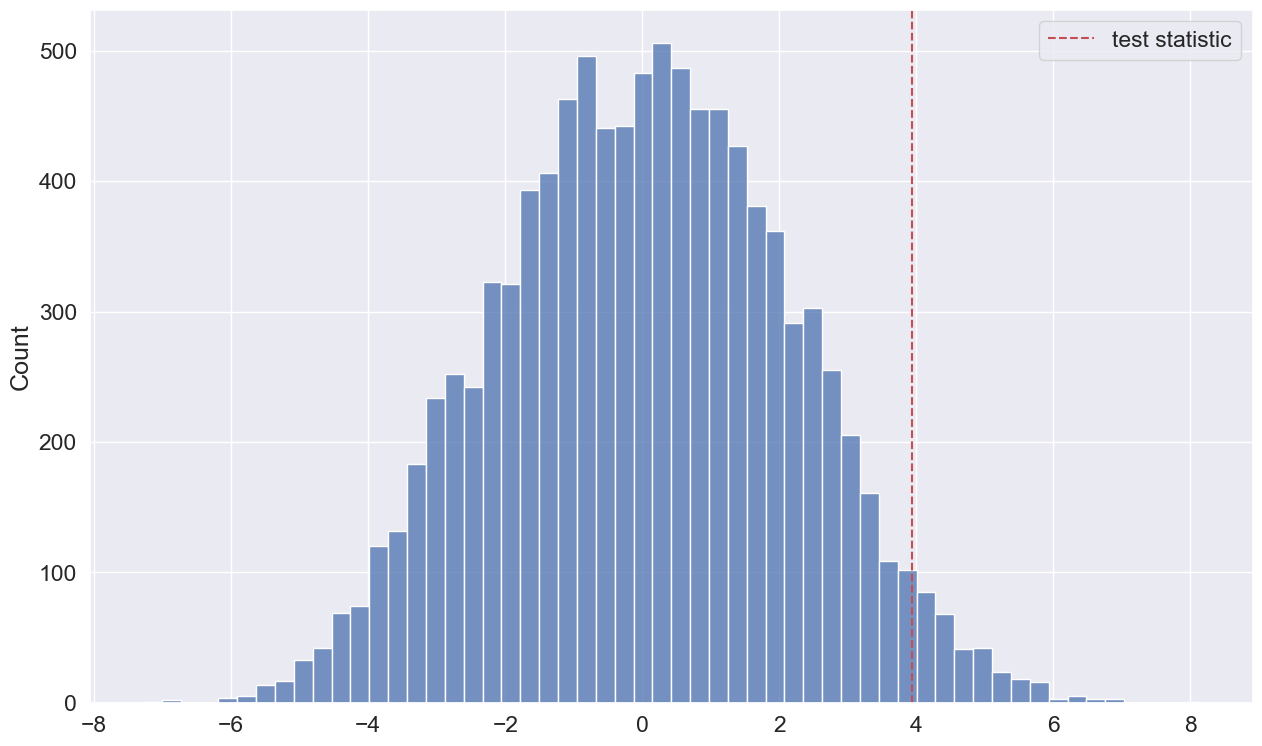

Average Simulated Test Statistic: 0.0228
Initially Observed Test Statistic: 3.9322


In [24]:
# PLOTTING

sns.histplot(mu_diff_samples)
plt.axvline(mu_diff, 0, 1, color='r', linestyle='--', label='test statistic')
plt.legend(loc='best')
plt.show()
print('Average Simulated Test Statistic:', f'{np.mean(mu_diff_samples):.4f}')
print('Initially Observed Test Statistic:', f'{mu_diff:.4f}')

In [25]:
# p-value

p_value = np.sum(np.abs(mu_diff_samples) >= np.abs(mu_diff)) / len(mu_diff_samples)

print(f"P-value: {p_value:.4f}")

P-value: 0.0612


**Answer question 4:**
Considering the typical significance level of 5%, our *p-value* is greater than 0.05, so we **cannot** reject the null hypothesis and conclude that there is no significant statistical difference between "fish" and "poultry".

### Part 2

The `distributions.csv` dataset from the `data` folder contains data drawn from 6 probability distributions – one per column. Load it to a DataFrame named `distributions` and check its contents.

In [26]:
distribution = pd.read_csv("data/distributions.csv")

distribution.head()

,distribution_1,distribution_2,distribution_3,distribution_4,distribution_5,distribution_6,distribution_7
0,False,100.004134,3.608307,890,1,-34,0.563827
1,False,100.008868,5.785856,897,1,-35,1.441859
2,False,100.004402,4.785344,898,3,-37,0.347664
3,False,100.000589,5.712047,890,0,-34,3.039330
4,False,100.017889,4.240379,898,1,-35,0.089587


1. Use the `.describe()` and `info()` methods on the `distributions` DataFrame to produce some preliminary information about each column. **What is the data type of each column?**

In [27]:
print(distribution.info())
print("")
print(distribution.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   distribution_1  1000 non-null   bool   
 1   distribution_2  1000 non-null   float64
 2   distribution_3  1000 non-null   float64
 3   distribution_4  1000 non-null   int64  
 4   distribution_5  1000 non-null   int64  
 5   distribution_6  1000 non-null   int64  
 6   distribution_7  1000 non-null   float64
dtypes: bool(1), float64(3), int64(3)
memory usage: 48.0 KB
None

       distribution_2  distribution_3  distribution_4  distribution_5  \
count     1000.000000     1000.000000     1000.000000     1000.000000   
mean       100.000263        3.462706      899.630000        1.192000   
std          0.010155        1.466874        9.729531        1.091938   
min         99.961668        1.002417      865.000000        0.000000   
25%         99.993916        2.223423      893.000000      

The data type of each column are:
1) `bool`: This is a binary distribution, meaning it only has True or False values (0 or 1).
2) `float64`: This is a distribution with real number ($\mathbb{R}$) values. From the `.describe()` output, we can see that the mean and median are close together, so it could be a Gaussian distribution. Also, the minimum and maximum are opposite in distance ($\sigma$) from the central value, which is close to the mean.
3) `float64`: similar to the previous case.
4) `int64`: This is a distribution with natural number ($\mathbb{N}$) values. It also seems to have a Gaussian distribution here, but the maximum value is closer to the minimum value, so it could have a tail.
5) `int64`: Similar to the previous one, but here the hint of a non-symmetrical distribution is given by the minimum and maximum values. I suggest the presence of longer tails at larger values.
6) `int64`: Still natural numbers distribution and a non perfectly simmetric distribution.
7) `float64`: Once again, we have a distribution of real numbers. The mean and median are different, so the distribution is not symmetrical.

2. Loop through each column of `distributions` and for each column produce a plot to show the distribution.

array([[<Axes: title={'center': 'distribution_2'}>,
        <Axes: title={'center': 'distribution_3'}>],
       [<Axes: title={'center': 'distribution_4'}>,
        <Axes: title={'center': 'distribution_5'}>],
       [<Axes: title={'center': 'distribution_6'}>,
        <Axes: title={'center': 'distribution_7'}>]], dtype=object)

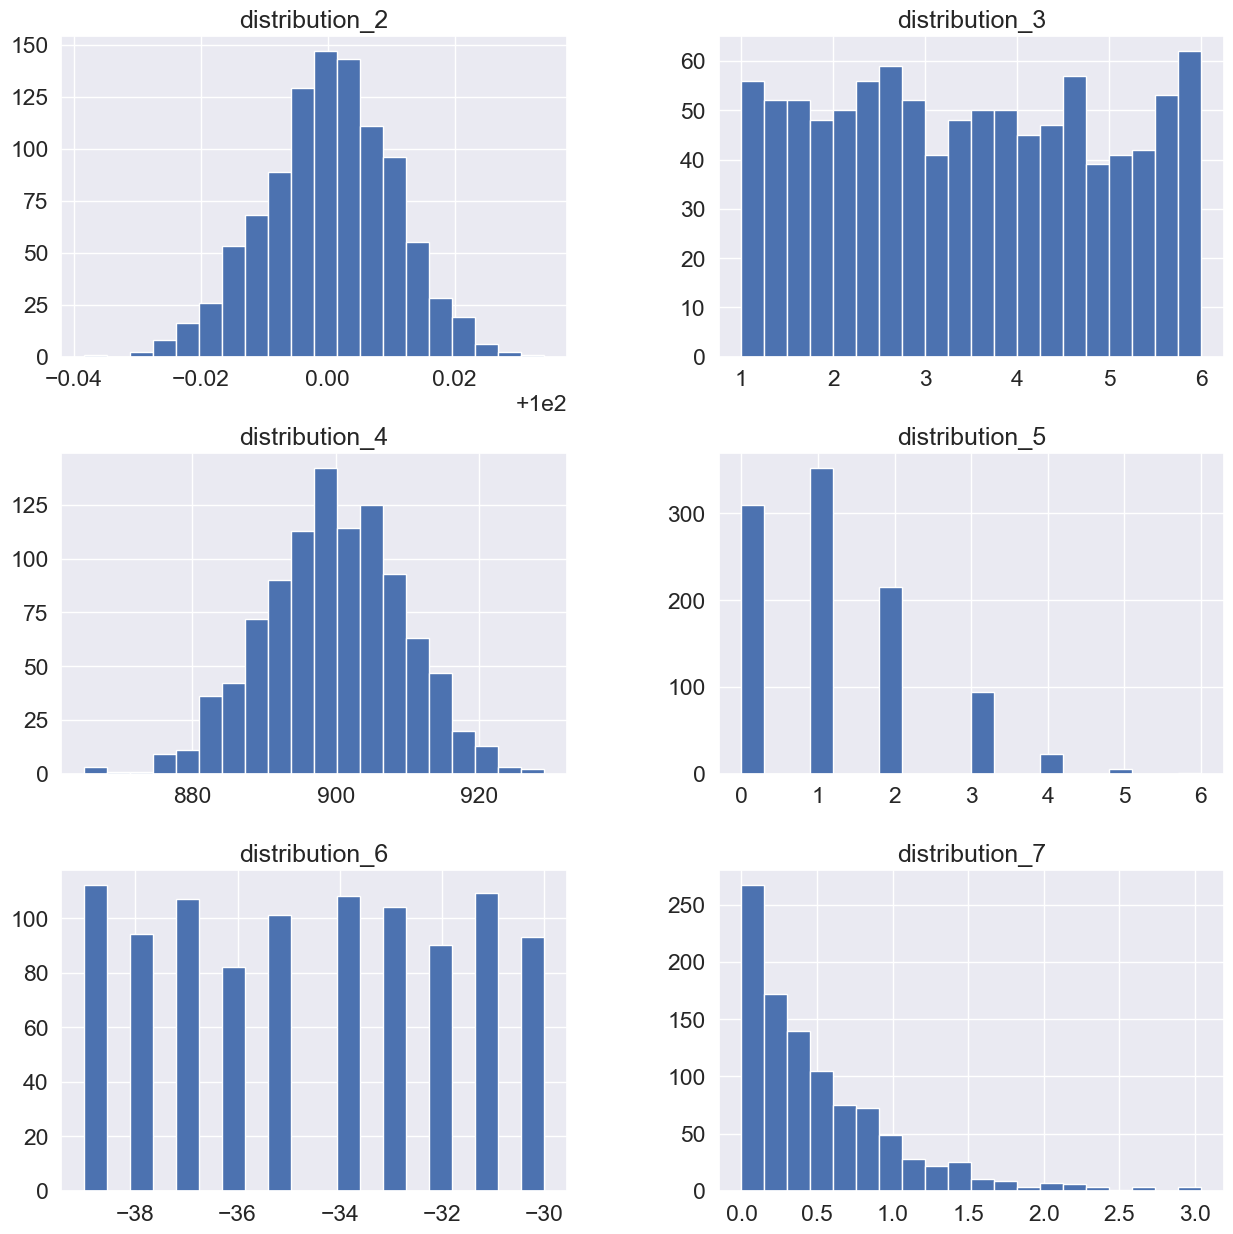

In [28]:
distribution.hist(bins=20, figsize=(15, 15))

3. Each column of the `distributions` dataframe contains data drawn from a different distribution. **Associate each column to its probability distribution.** This is the list of the probability distributions used (one for each column):
    - Bernoulli
    - Binomial
    - Continuous Uniform
    - Gaussian (Normal)
    - Discrete Uniform
    - Poisson
    - Exponential (this was not explain in classroom, go by exclusion)

In [29]:
distribution_dict = {'distribution_1': 'Bernoulli',
                     'distribution_2': 'Binomial',
                     'distribution_3': 'Continuous Uniform',
                     'distribution_4': 'Gaussian',
                     'distribution_6': 'Discrete Uniform',
                     'distribution_5': 'Poisson',
                     'distribution_7': 'Exponential'
                     }

# setting the distribution type

distribution_fixed = distribution.copy()

distribution_fixed.rename(columns=distribution_dict, inplace=True)

distribution_fixed.head()

,Bernoulli,Binomial,Continuous Uniform,Gaussian,Poisson,Discrete Uniform,Exponential
0,False,100.004134,3.608307,890,1,-34,0.563827
1,False,100.008868,5.785856,897,1,-35,1.441859
2,False,100.004402,4.785344,898,3,-37,0.347664
3,False,100.000589,5.712047,890,0,-34,3.039330
4,False,100.017889,4.240379,898,1,-35,0.089587


array([[<Axes: title={'center': 'Binomial'}>,
        <Axes: title={'center': 'Continuous Uniform'}>],
       [<Axes: title={'center': 'Gaussian'}>,
        <Axes: title={'center': 'Poisson'}>],
       [<Axes: title={'center': 'Discrete Uniform'}>,
        <Axes: title={'center': 'Exponential'}>]], dtype=object)

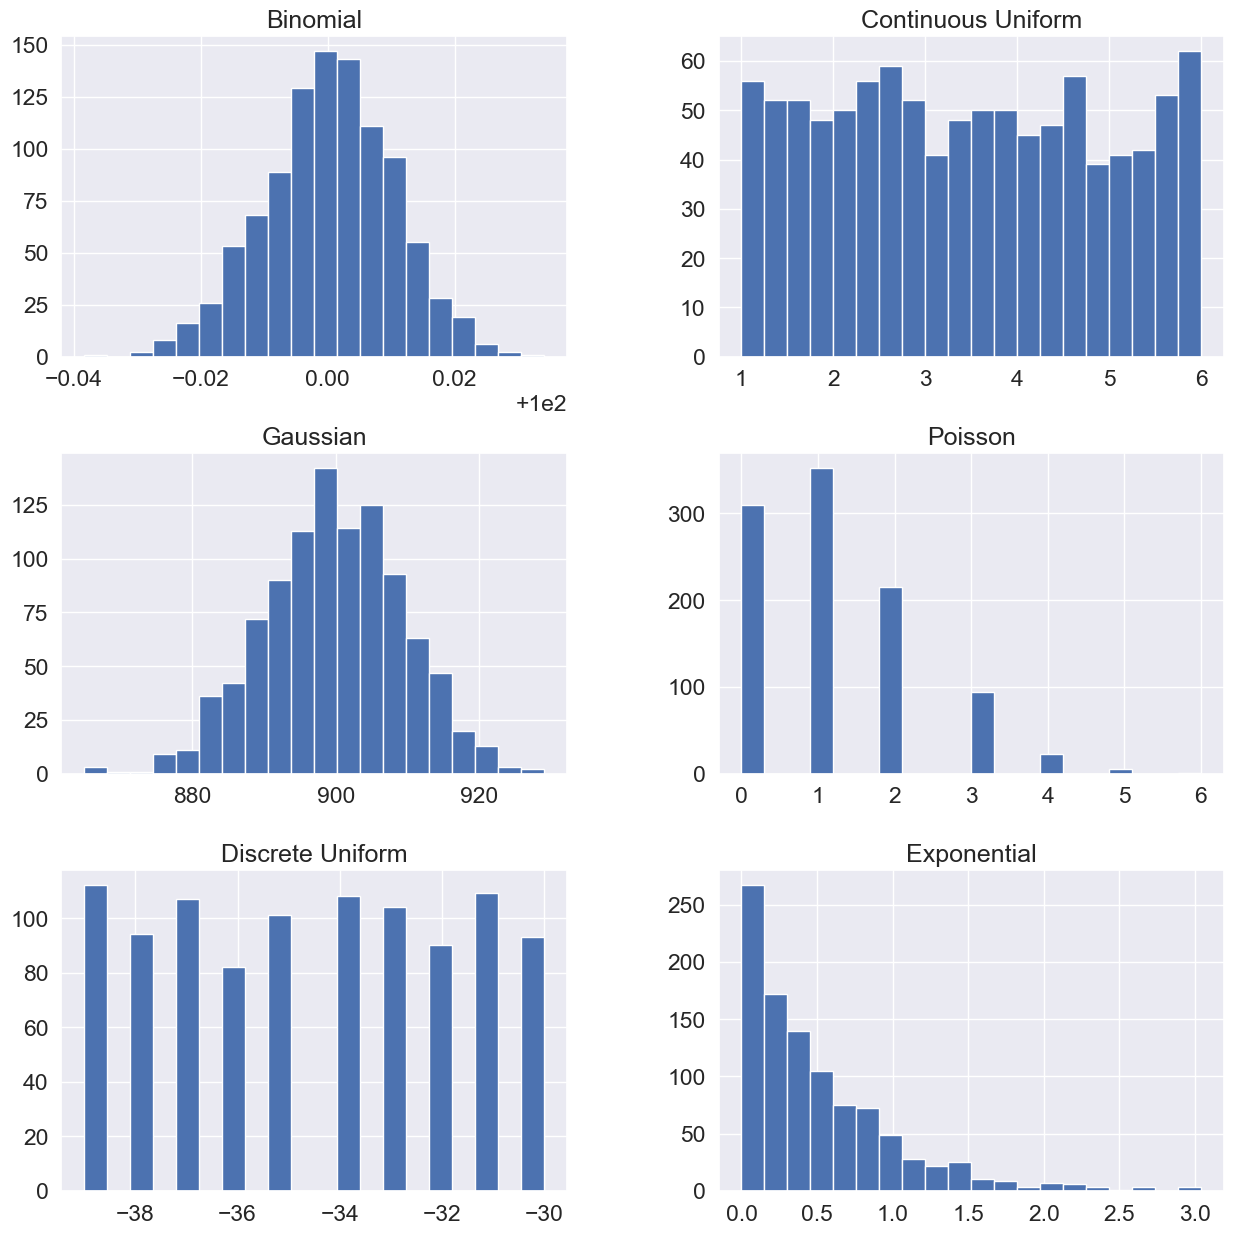

In [30]:
distribution_fixed.hist(bins=20, figsize=(15, 15))